In [6]:
import numpy as np
import matplotlib.pyplot as plt
from geometry_class import Geometry
from parametrizations import Parameter
from visualization_fct import get_grid, eval_fct_on_grid
from dolfinx.fem import functionspace, Function, Expression
import pickle
from basix.ufl import element
import ufl
from scipy.interpolate import griddata

In [7]:
filename = "./solutions/isothermal_test_newbc.pkl"
with open(filename, "rb") as f:
    data_Annika = pickle.load(f)

nx = data_Annika["geometry"]["nx"]
nz = data_Annika["geometry"]["nz"]
geom = Geometry()
geom.make_from_dict(data_Annika["geometry"])
domain = geom.make_domain(nx, nz)
[P0, P1, P2, P3] = geom.corner_points
V = functionspace(domain, ("CG", 1))
Q = functionspace(domain, ("DG", 0))
hw = Function(V)
phi = Function(Q)
layer_params = {
    1: {
        "d_i": 2.31e-4,
        "rho_s": 387,
        "locator": lambda x: x[1] >= geom.slope*x[0] + P3[1]/2 - 1e-14,
        "Ks": 4.764},
    2: {
        "d_i": 4.21e-4,
        "rho_s": 489,
        "locator": lambda x: x[1] < geom.slope*x[0] + P3[1]/2 - 1e-14,
        "Ks": 5.298}
}
p = Parameter(domain, layer_params)

In [8]:
t_obs = 10
hw.x.array[:] = data_Annika["h_w"][t_obs]
phi.x.array[:] = data_Annika["phi"]
grid, x_plot, z_plot = get_grid(P0, P1, P2, P3, nx, nz)
pressure_head = eval_fct_on_grid(grid, hw, domain).reshape((nz, nx))
porosity = eval_fct_on_grid(grid, phi, domain).reshape((nz, nx))
alpha_eval = eval_fct_on_grid(grid, p.alpha, domain).reshape((nz, nx))
N_eval = eval_fct_on_grid(grid, p.N, domain).reshape((nz, nx))
h_c = pressure_head * (pressure_head < 0)
def Se(h_c, alpha, N):
    return (1 + (- alpha * h_c)**N)**((1 - N) / N)
theta_tot = p.theta_r.value + (0.9*porosity - p.theta_r.value)*Se(h_c, alpha_eval, N_eval)
z_eval = grid[:,1].reshape((nz, nx))
h_tot = pressure_head + z_eval
d_i_eval = eval_fct_on_grid(grid, p.d_i, domain).reshape((nz, nx))


In [9]:
# Calculate specific discharge
Vq = functionspace(domain, element("DG", domain.basix_cell(), 0, shape=(2,)))
z = ufl.SpatialCoordinate(domain)[1]
h_c = ufl.min_value(hw, 0.0)
Se = (1 + (-p.alpha*h_c)**p.N)**((1-p.N)/p.N)
m = 1 - 1/p.N
kr = Se**0.5 * (1 - (1-Se**(1/m))**m)**2
Ks = (
    3*(p.d_i/2)**2
    * ufl.exp(-0.013*p.rho_i*(1-phi))
    * p.rho_w*p.g/p.mu_w
)
h_tot = hw + z
q_expr = -Ks * kr * ufl.grad(h_tot)
q = Function(Vq)
expr = Expression(q_expr, Vq.element.interpolation_points)
q.interpolate(expr)
q_eval = eval_fct_on_grid(grid, q, domain)
q_x = q_eval[:,0].reshape((nz, nx))
q_z = q_eval[:,1].reshape((nz, nx))

In [7]:
t_obs = 24
hw.x.array[:] = data_Annika["h_w"][t_obs]
porosity = 0.468
grid, x_plot, z_plot = get_grid(P0, P1, P2, P3, nx, nz)
pressure_head = eval_fct_on_grid(grid, hw, domain).reshape((nz, nx))
h_c = pressure_head * (pressure_head < 0)
def Se(h_c, alpha, N):
    return (1 + (- alpha * h_c)**N)**((1 - N) / N)
theta_tot = p.theta_r.value + (0.9*porosity - p.theta_r.value)*Se(h_c, p.alpha.value, p.N.value)
h_tot = pressure_head + grid[:,1].reshape((nz, nx))

AttributeError: 'Function' object has no attribute 'value'

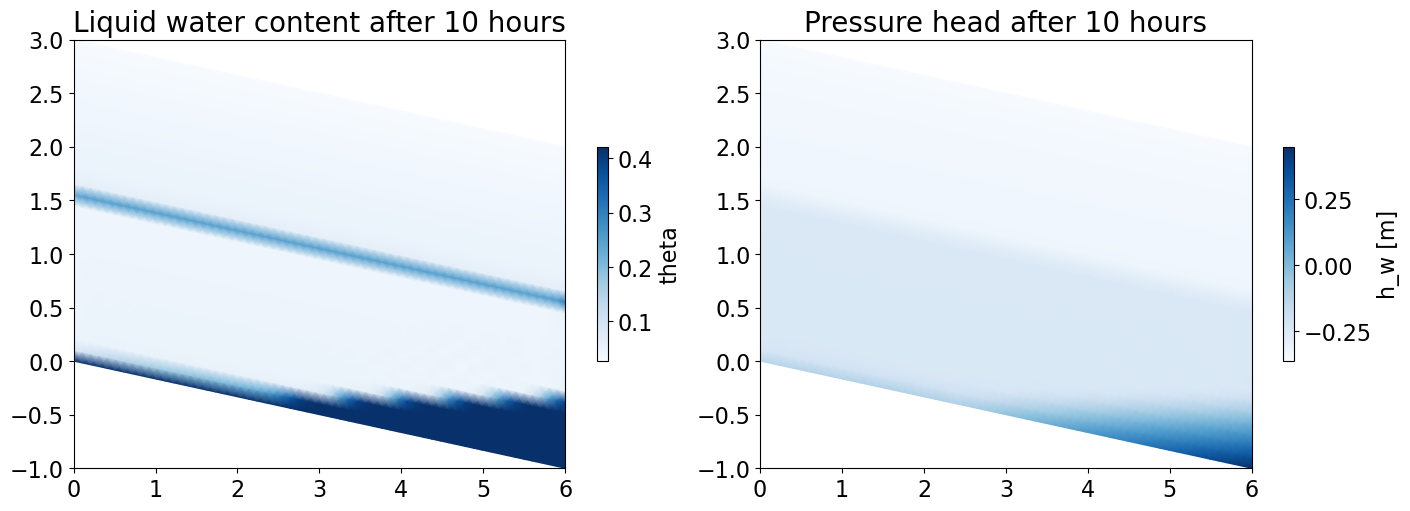

In [10]:
plt.rcParams.update({'font.size': 16})
fig, ax = plt.subplots(1,2, layout="constrained", figsize=(14,5))
pmsh1 = ax[0].pcolormesh(x_plot, z_plot, theta_tot, cmap="Blues", shading="gouraud")
ax[0].set_title(f"Liquid water content after {t_obs} hours", fontsize=20)
cbar1 = fig.colorbar(pmsh1, ax=ax[0], shrink=0.5)
cbar1.set_label("theta")

pmsh2 = ax[1].pcolormesh(x_plot, z_plot, pressure_head, cmap="Blues", shading="gouraud")
ax[1].set_title(f"Pressure head after {t_obs} hours", fontsize=20)
plt.xticks(fontsize=16)
cbar2 = fig.colorbar(pmsh2, ax=ax[1], shrink=0.5)
cbar2.set_label("h_w [m]")

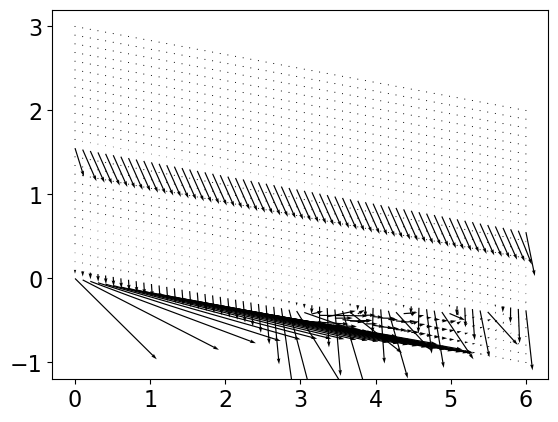

In [6]:
plt.quiver(grid[:,0], grid[:,1], q_x, q_z)

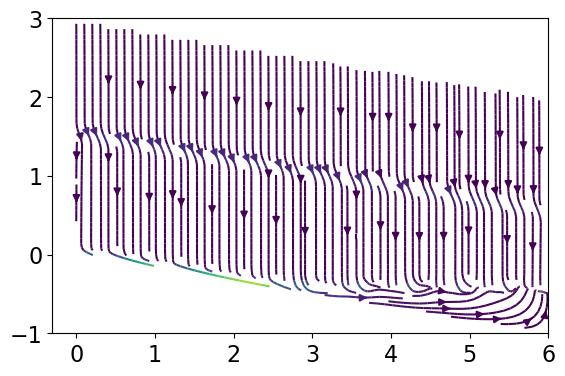

In [7]:
# Plot q as streamlines
points = np.column_stack((x_plot.ravel(), z_plot.ravel()))

x = np.linspace(x_plot.min(), x_plot.max(), 250)
z = np.linspace(z_plot.min(), z_plot.max(), 250)
X, Z = np.meshgrid(x, z)

Qx = griddata(points, q_x.ravel(), (X, Z), method="linear")
Qz = griddata(points, q_z.ravel(), (X, Z), method="linear")

plt.streamplot(
    X, Z,
    Qx, Qz,
    density=2,
    color=np.sqrt(Qx**2 + Qz**2)
)

plt.gca().set_aspect("equal")
plt.show()